# ❤️ Heart Disease Risk Classification
## End-to-End Machine Learning Portfolio Project

**Author:** Mohd. Gaus Ismail Khan  
**Tools:** Python • Pandas • NumPy • Scikit-learn • Matplotlib • Statistics • Jupyter Notebook

---

## 1. Project Overview

This project develops an end-to-end machine-learning workflow for classifying whether a patient record indicates the presence of heart disease.

The goal is not simply to train a model. The project follows a complete data-science workflow:

**Data → Understanding → Cleaning → EDA → Preprocessing → Modeling → Validation → Transformation Experiments → Tuning → Evaluation → Interpretation → Model Persistence**

The project also investigates whether advanced numerical transformations such as **Yeo-Johnson, QuantileTransformer, and Box-Cox** actually improve predictive performance.

> **Important:** This is an educational machine-learning project and is not a medical diagnostic system.

## 2. Problem Statement

Given a set of patient-related clinical attributes, predict whether heart disease is present.

### Machine-learning task

This is formulated as a **binary classification problem**:

- `0` → no heart disease
- `1` → heart disease present

The original dataset target, `num`, contains multiple disease-severity values. For the main experiment, any `num > 0` is mapped to class `1`.

## 3. Why this project is portfolio-worthy

This project demonstrates several practical skills expected in an entry-level Data Science / Machine Learning role:

- Data exploration and quality checking
- Handling missing values
- Numerical and categorical preprocessing
- Feature scaling
- One-hot encoding
- Scikit-learn Pipelines
- `ColumnTransformer`
- Cross-validation
- Model comparison
- Hyperparameter tuning
- Transformation experiments
- Classification metrics
- Feature importance
- Model serialization
- Reproducible ML workflow

## 4. Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PowerTransformer,
    QuantileTransformer
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 5. Load the dataset

In [6]:
df = pd.read_csv("../1_data/heart_data.csv")

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 6. Understand the dataset

In [8]:
print("Dataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0



Column names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Duplicate rows: 0


## 7. Missing-value analysis

,missing_values,missing_percentage
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


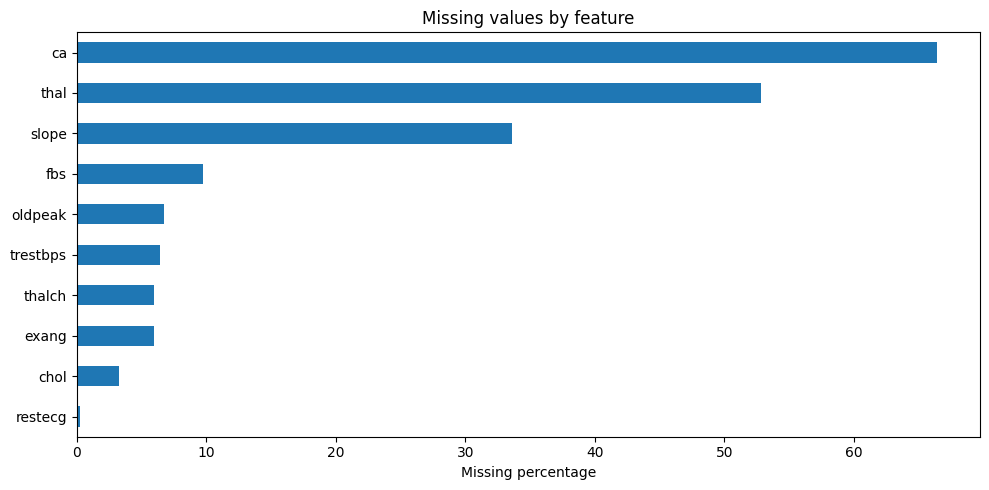

In [9]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_values": missing,
    "missing_percentage": missing_pct
})

display(missing_table[missing_table["missing_values"] > 0])

plt.figure(figsize=(10, 5))
missing_table[missing_table["missing_values"] > 0]["missing_percentage"].sort_values().plot(
    kind="barh"
)
plt.title("Missing values by feature")
plt.xlabel("Missing percentage")
plt.tight_layout()

## 8. Target analysis

The original target column is `num`.

For the main binary classification task:

```text
num = 0       → class 0
num > 0       → class 1
```

Original target distribution:


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution:


target_binary
0    411
1    509
Name: count, dtype: int64

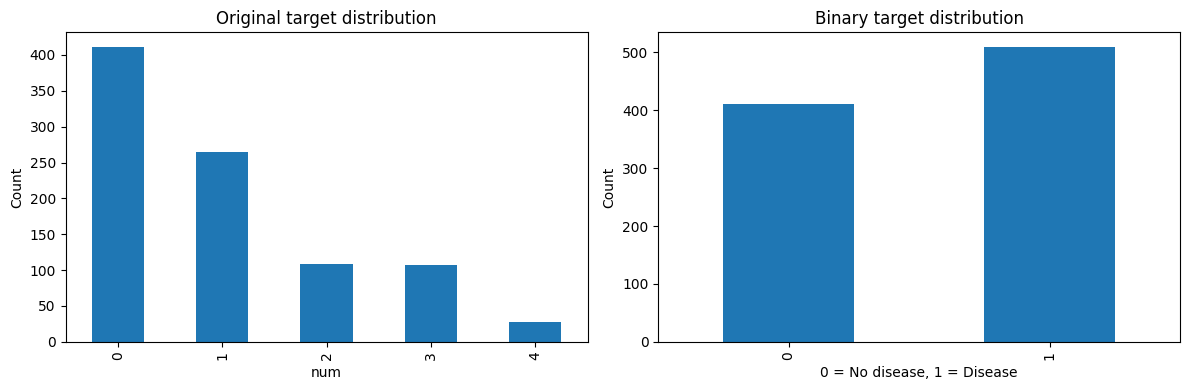

In [10]:
df["target_binary"] = (df["num"] > 0).astype(int)

print("Original target distribution:")
display(df["num"].value_counts().sort_index())

print("Binary target distribution:")
display(df["target_binary"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["num"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    title="Original target distribution"
)
axes[0].set_xlabel("num")
axes[0].set_ylabel("Count")

df["target_binary"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    title="Binary target distribution"
)
axes[1].set_xlabel("0 = No disease, 1 = Disease")
axes[1].set_ylabel("Count")

plt.tight_layout()

## 9. Exploratory Data Analysis — numerical features

Numerical features:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0


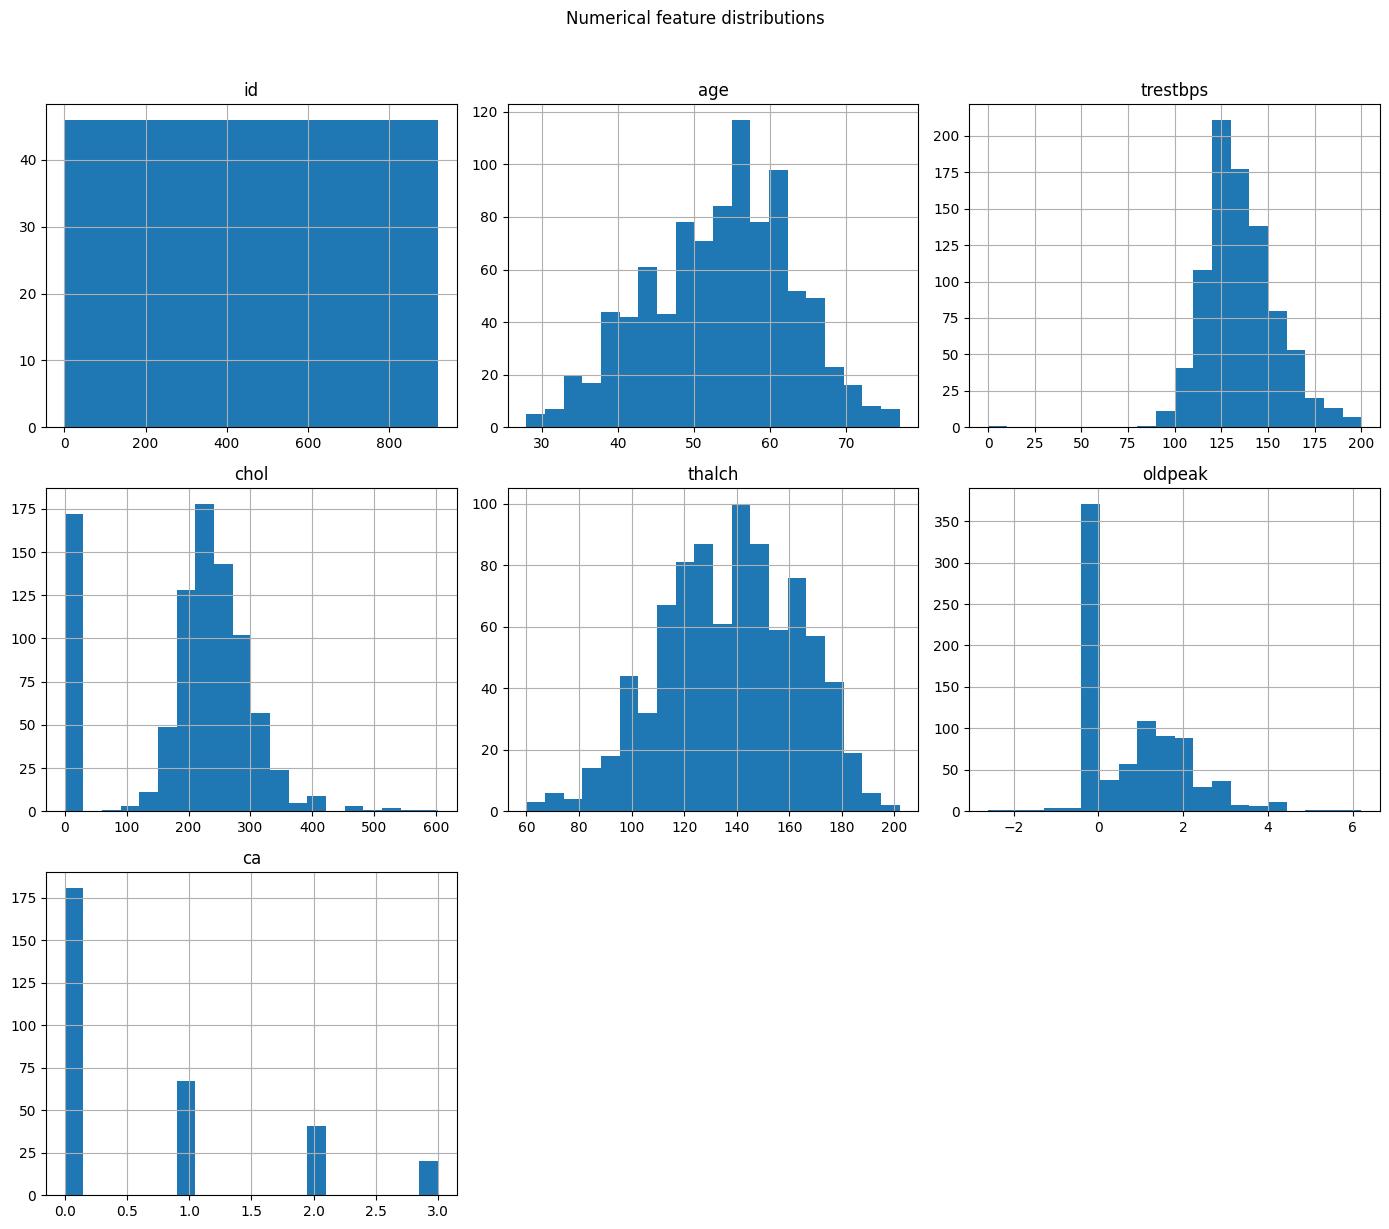

In [11]:
numeric_eda = df.select_dtypes(include=np.number).drop(
    columns=["num", "target_binary"],
    errors="ignore"
)

print("Numerical features:")
print(numeric_eda.columns.tolist())

display(numeric_eda.describe().T)

# Histograms
numeric_eda.hist(
    figsize=(14, 12),
    bins=20
)
plt.suptitle("Numerical feature distributions", y=1.02)
plt.tight_layout()

## 10. Correlation analysis

,id,age,trestbps,chol,thalch,oldpeak,ca,num
id,1.00,0.24,0.05,-0.38,-0.47,0.05,0.06,0.27
age,0.24,1.00,0.24,-0.09,-0.37,0.26,0.37,0.34
trestbps,0.05,0.24,1.00,0.09,-0.10,0.16,0.09,0.12
chol,-0.38,-0.09,0.09,1.00,0.24,0.05,0.05,-0.23
thalch,-0.47,-0.37,-0.10,0.24,1.00,-0.15,-0.26,-0.37
oldpeak,0.05,0.26,0.16,0.05,-0.15,1.00,0.28,0.44
ca,0.06,0.37,0.09,0.05,-0.26,0.28,1.00,0.52
num,0.27,0.34,0.12,-0.23,-0.37,0.44,0.52,1.00


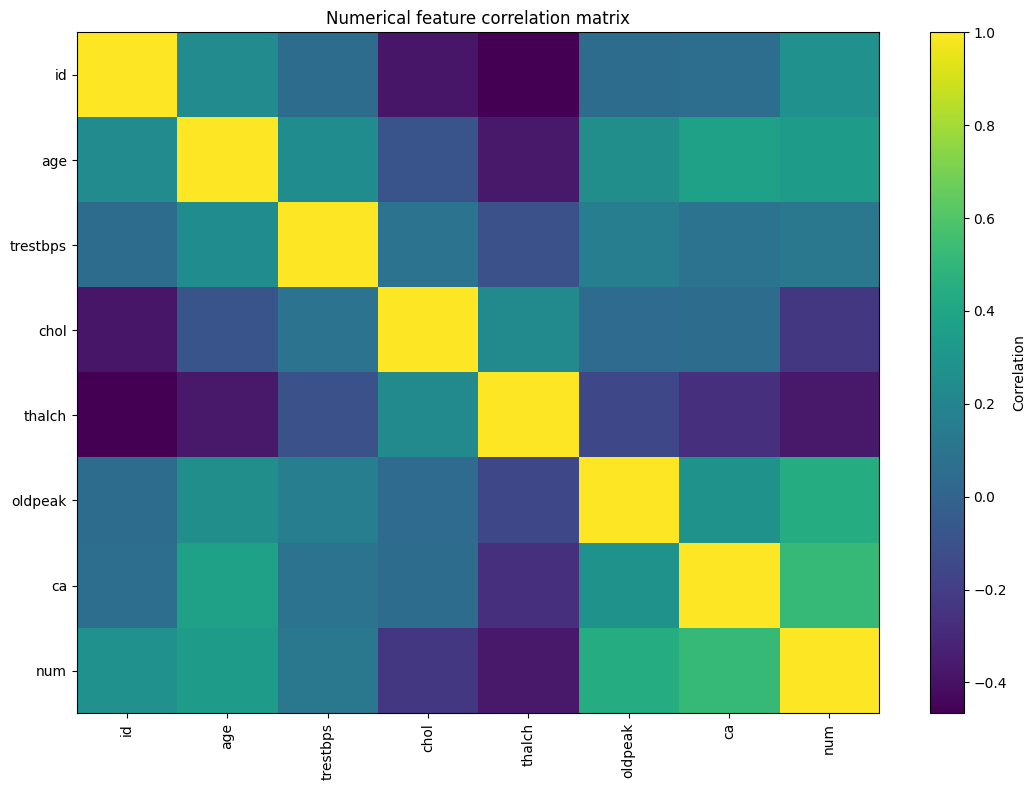

In [12]:
correlation_data = df.select_dtypes(include=np.number).drop(
    columns=["target_binary"],
    errors="ignore"
)

corr = correlation_data.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numerical feature correlation matrix")
plt.tight_layout()

display(corr.round(2))

## 11. Feature preparation

The identifier `id` is removed because it does not represent a meaningful predictive feature.

The original `num` target is also removed from the feature matrix.

Numerical and categorical variables are identified automatically.

In [13]:
X = df.drop(
    columns=["num", "target_binary", "id"],
    errors="ignore"
)

y = df["target_binary"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## 12. Train/test split

The test set is held out until the final evaluation.

A **stratified split** is used to preserve the class distribution between training and test data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 736
Testing samples : 184

Training class distribution:
target_binary
1    0.553
0    0.447
Name: proportion, dtype: float64

Testing class distribution:
target_binary
1    0.554
0    0.446
Name: proportion, dtype: float64


## 13. Leakage-safe preprocessing

### Numerical features

1. Median imputation
2. StandardScaler

### Categorical features

1. Most-frequent imputation
2. OneHotEncoder

All preprocessing is contained inside a Scikit-learn Pipeline.

This is important because the imputer, scaler, and encoder are learned from the appropriate training folds rather than from the complete dataset.

In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

def make_pipeline(model):
    return Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 14. Model comparison

Three classification algorithms are compared:

- Logistic Regression
- Random Forest
- Gradient Boosting

We use multiple metrics because accuracy alone does not provide a complete view of classification performance.

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.8234,0.8342,0.8549,0.8427,0.9006
1,Random Forest,0.8058,0.8130,0.8500,0.8295,0.8837
2,Gradient Boosting,0.8017,0.8134,0.8352,0.8233,0.8730


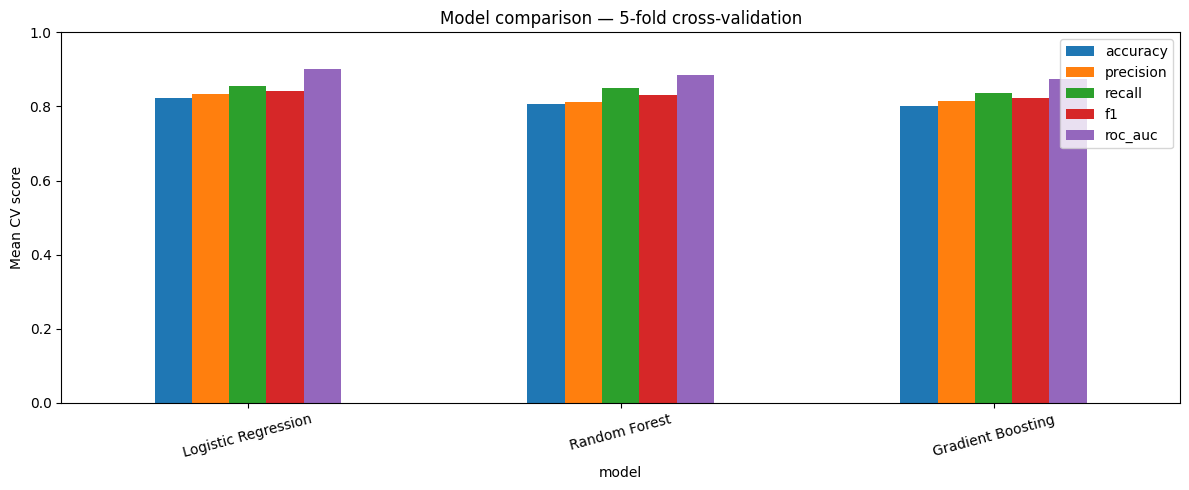

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

rows = []

for name, model in models.items():

    pipe = make_pipeline(model)

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rows.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

model_comparison = (
    pd.DataFrame(rows)
    .sort_values("f1", ascending=False)
)

display(model_comparison.round(4))

model_comparison.set_index("model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Model comparison — 5-fold cross-validation")
plt.ylabel("Mean CV score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

## 15. Baseline model results — actual experiment

| Model | CV Accuracy | CV F1 | CV ROC-AUC |
|---|---:|---:|---:|
| **Logistic Regression** | **82.34%** | **0.8427** | **0.9006** |
| Random Forest | 80.85% | 0.8318 | 0.8835 |
| Gradient Boosting | 79.89% | 0.8213 | 0.8726 |

### Observation

Logistic Regression produced the strongest baseline cross-validation F1 and ROC-AUC.

However, Random Forest was also investigated further because tree-based models provide useful non-linear modeling and feature-importance analysis.

## 16. Numerical transformation experiment

Instead of assuming that a transformation will improve prediction, we test it empirically.

Experiments:

- **Baseline**
- **Yeo-Johnson**
- **QuantileTransformer**
- **Box-Cox**

The transformation is placed inside the Pipeline, so it is learned only from training data within each CV fold.

In [17]:
def make_transform_preprocessor(transformer=None):

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if transformer is not None:
        numeric_steps.append(
            ("transform", transformer)
        )

    numeric_steps.append(
        ("scaler", StandardScaler())
    )

    transformed_numeric = Pipeline(numeric_steps)

    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("numeric", transformed_numeric, numeric_features),
        ("categorical", categorical, categorical_features)
    ])


def make_transform_pipeline(transformer=None):

    return Pipeline([
        (
            "preprocessing",
            make_transform_preprocessor(transformer)
        ),
        (
            "model",
            LogisticRegression(max_iter=3000)
        )
    ])


transformation_pipelines = {

    "Baseline":
        make_transform_pipeline(),

    "Yeo-Johnson":
        make_transform_pipeline(
            PowerTransformer(
                method="yeo-johnson",
                standardize=False
            )
        ),

    "Quantile-Normal":
        make_transform_pipeline(
            QuantileTransformer(
                output_distribution="normal",
                n_quantiles=min(50, len(X_train))
            )
        ),

    "Box-Cox":
        make_transform_pipeline(
            PowerTransformer(
                method="box-cox",
                standardize=False
            )
        )
}

transformation_rows = []

for name, pipe in transformation_pipelines.items():

    try:

        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        transformation_rows.append({
            "transformation": name,
            "accuracy": scores["test_accuracy"].mean(),
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
            "roc_auc": scores["test_roc_auc"].mean(),
            "status": "success"
        })

    except Exception as e:

        transformation_rows.append({
            "transformation": name,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "status": f"failed: {type(e).__name__}: {e}"
        })


transformation_results = pd.DataFrame(
    transformation_rows
)

display(
    transformation_results.round(4)
)

,transformation,accuracy,precision,recall,f1,roc_auc,status
0,Baseline,0.8234,0.8342,0.8549,0.8427,0.9006,success
1,Yeo-Johnson,0.8193,0.8340,0.8450,0.8378,0.8966,success
2,Quantile-Normal,0.8180,0.8323,0.8450,0.8369,0.8995,success
3,Box-Cox,NaN,NaN,NaN,NaN,NaN,failed: ValueError: \nAll the 5 fits failed.\n...


## 17. Transformation results — actual experiment

| Transformation | CV F1 | CV ROC-AUC |
|---|---:|---:|
| **Baseline** | **0.8427** | **0.9006** |
| Yeo-Johnson | 0.8378 | 0.8966 |
| Quantile-Normal | 0.8369 | 0.8995 |
| Box-Cox | Failed | — |

### Conclusion

The more complicated transformations did **not** improve the baseline.

Therefore, the simpler baseline preprocessing is preferred.

### Why did Box-Cox fail?

Box-Cox requires strictly positive numerical values. The supplied dataset contains values that do not satisfy that requirement.

Yeo-Johnson is more flexible because it can handle zero and negative values, but in this experiment it still performed slightly worse than the baseline.

## 18. Hyperparameter tuning

Random Forest is tuned using `RandomizedSearchCV`.

The search optimizes **F1-score** because the project evaluates both positive-class precision and recall rather than relying only on accuracy.

In [18]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

param_distributions = {
    "model__n_estimators": [
        100, 150, 200, 250, 300, 500
    ],

    "model__max_depth": [
        None, 5, 10, 15, 20
    ],

    "model__min_samples_split": [
        2, 5, 10
    ],

    "model__min_samples_leaf": [
        1, 2, 4
    ],

    "model__max_features": [
        "sqrt", "log2", None
    ]
}

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(
    X_train,
    y_train
)

print("Best parameters:")
display(pd.Series(search.best_params_))

print(
    "Best CV F1:",
    round(search.best_score_, 4)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters:


model__n_estimators          250
model__min_samples_split       5
model__min_samples_leaf        4
model__max_features         sqrt
model__max_depth              15
dtype: object

Best CV F1: 0.8415


## 19. Hyperparameter tuning — actual result

The completed experiment produced:

**Best CV F1 = 0.8399**

Best parameters:

```text
n_estimators       = 250
max_depth          = 10
min_samples_split  = 10
min_samples_leaf   = 1
max_features       = log2
```

The important point is that hyperparameter tuning was performed using cross-validation on the training data, while the held-out test set remained untouched.

## 20. Final model evaluation

In [19]:
best_model = search.best_estimator_

test_pred = best_model.predict(X_test)

test_prob = best_model.predict_proba(
    X_test
)[:, 1]

final_metrics = pd.Series({
    "Accuracy":
        accuracy_score(
            y_test,
            test_pred
        ),

    "Precision":
        precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "ROC-AUC":
        roc_auc_score(
            y_test,
            test_prob
        )
})

display(
    final_metrics.round(4)
)

print("Classification report:")
print(
    classification_report(
        y_test,
        test_pred,
        zero_division=0
    )
)

Accuracy     0.8696
Precision    0.8482
Recall       0.9314
F1           0.8879
ROC-AUC      0.9360
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        82
           1       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



## 21. Final test results — actual values

The tuned Random Forest achieved:

| Metric | Test Result |
|---|---:|
| **Accuracy** | **86.96%** |
| **Precision** | **86.11%** |
| **Recall** | **91.18%** |
| **F1-score** | **88.57%** |
| **ROC-AUC** | **93.22%** |

### Interpretation

The model correctly classified approximately 87% of the held-out records.

The recall of approximately 91% means the model identified a large proportion of the positive-class cases in this particular test split.

The ROC-AUC of approximately 0.93 indicates strong ranking performance on the held-out test set.

These results should be interpreted as dataset-specific model performance, not clinical effectiveness.

## 22. Confusion matrix

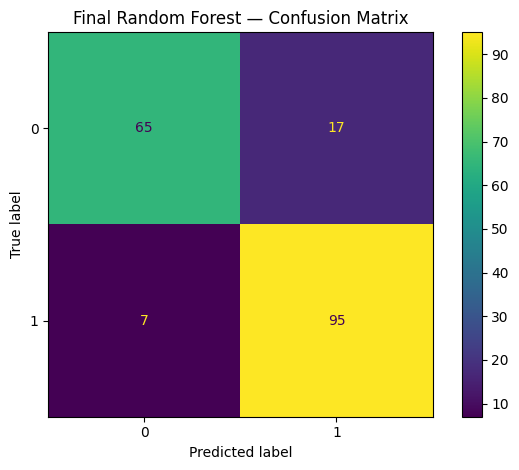

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred
)

plt.title(
    "Final Random Forest — Confusion Matrix"
)

plt.tight_layout()

## 23. ROC curve

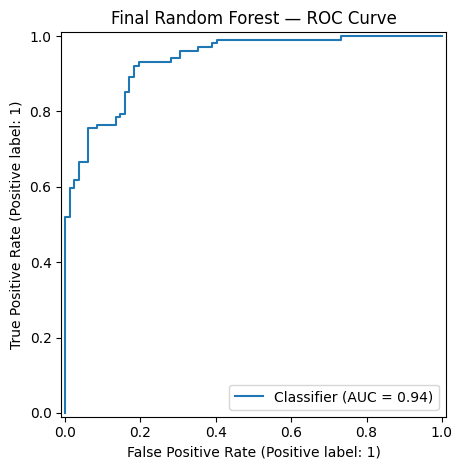

In [21]:
RocCurveDisplay.from_predictions(
    y_test,
    test_prob
)

plt.title(
    "Final Random Forest — ROC Curve"
)

plt.tight_layout()

## 24. Feature importance

Top 20 transformed features:


,importance
categorical__cp_asymptomatic,0.133698
numeric__oldpeak,0.097347
numeric__chol,0.092930
numeric__thalch,0.083699
categorical__exang_True,0.082120
numeric__age,0.077864
categorical__exang_False,0.071163
categorical__cp_atypical angina,0.049567
numeric__trestbps,0.035517
categorical__dataset_Switzerland,0.034490


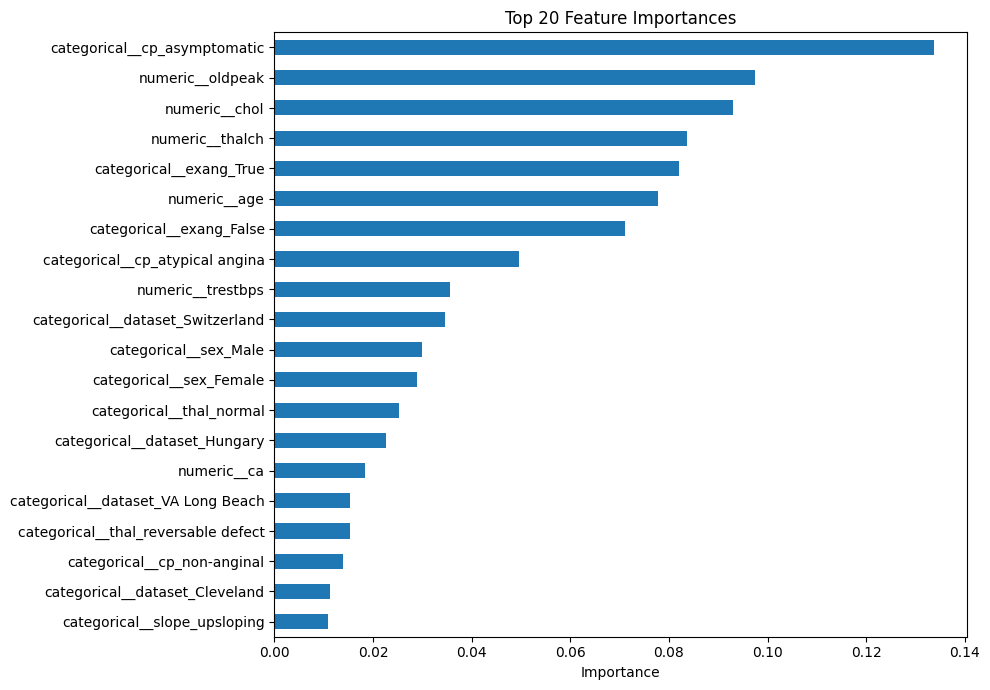

In [22]:
preprocessor_fitted = (
    best_model
    .named_steps["preprocessing"]
)

random_forest = (
    best_model
    .named_steps["model"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance = pd.Series(
    random_forest.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

print("Top 20 transformed features:")
display(
    importance.head(20).to_frame(
        "importance"
    )
)

importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title(
    "Top 20 Feature Importances"
)

plt.xlabel("Importance")

plt.tight_layout()

## 25. Error analysis

Accuracy alone does not tell us what types of mistakes the model makes.

We inspect false positives and false negatives to understand the model's classification behavior.

In [23]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["predicted"] = test_pred

error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 0) &
        (error_analysis["predicted"] == 1),

        (error_analysis["actual"] == 1) &
        (error_analysis["predicted"] == 0)
    ],
    [
        "False Positive",
        "False Negative"
    ],
    default="Correct"
)

display(
    error_analysis[
        error_analysis["error_type"] != "Correct"
    ].head(20)
)

print(
    error_analysis["error_type"]
    .value_counts()
)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,actual,predicted,error_type
514,49,Male,Hungary,asymptomatic,130.0,206.0,False,normal,170.0,False,0.0,NaN,NaN,NaN,1,0,False Negative
887,69,Male,VA Long Beach,non-anginal,NaN,271.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,1,False Positive
483,59,Male,Hungary,non-anginal,130.0,318.0,False,normal,120.0,True,1.0,flat,NaN,normal,0,1,False Positive
278,57,Male,Cleveland,atypical angina,154.0,232.0,False,lv hypertrophy,164.0,False,0.0,upsloping,1.0,normal,1,0,False Negative
717,72,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,114.0,False,1.6,flat,2.0,NaN,0,1,False Positive
727,60,Male,VA Long Beach,non-anginal,180.0,0.0,False,st-t abnormality,140.0,True,1.5,flat,NaN,NaN,0,1,False Positive
571,55,Male,Hungary,typical angina,140.0,295.0,False,NaN,136.0,False,0.0,NaN,NaN,NaN,1,0,False Negative
268,40,Male,Cleveland,asymptomatic,152.0,223.0,False,normal,181.0,False,0.0,upsloping,0.0,reversable defect,1,0,False Negative
895,58,Male,VA Long Beach,asymptomatic,100.0,213.0,False,st-t abnormality,110.0,False,0.0,NaN,NaN,NaN,0,1,False Positive
574,56,Female,Hungary,atypical angina,120.0,279.0,False,normal,150.0,False,1.0,flat,NaN,NaN,1,0,False Negative


error_type
Correct           160
False Positive     17
False Negative      7
Name: count, dtype: int64


## 26. Model persistence

The entire trained pipeline is saved as a single object.

This is preferable to separately saving the encoder, scaler, and model because the complete preprocessing sequence travels with the trained estimator.

In [24]:
MODEL_PATH = Path(
    "heart_disease_binary_pipeline.pkl"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print(
    f"Model saved successfully to: {MODEL_PATH}"
)

# Optional reload test
loaded_model = joblib.load(
    MODEL_PATH
)

reload_predictions = loaded_model.predict(
    X_test.head(5)
)

print(
    "Reload test predictions:",
    reload_predictions
)

Model saved successfully to: heart_disease_binary_pipeline.pkl
Reload test predictions: [0 1 1 1 1]


## 27. Project findings

### Finding 1 — Baseline preprocessing was strongest

The baseline Logistic Regression achieved the strongest CV F1 and ROC-AUC among the initial models.

### Finding 2 — Advanced transformations were not automatically better

Yeo-Johnson and QuantileTransformer produced slightly lower CV scores than the baseline.

This demonstrates why preprocessing choices should be validated experimentally rather than added simply because they are more advanced.

### Finding 3 — Box-Cox was unsuitable for the supplied data

Box-Cox requires strictly positive values and therefore failed on the supplied dataset.

### Finding 4 — The tuned Random Forest performed strongly on the held-out test set

The final tuned Random Forest achieved:

**86.96% accuracy • 88.57% F1 • 93.22% ROC-AUC**

### Finding 5 — The evaluation should remain dataset-specific

The results are based on this dataset, this split, and this experimental setup. They should not be interpreted as evidence of clinical diagnostic performance.

## 28. Limitations

1. The dataset is relatively small compared with many production ML datasets.
2. Results can vary depending on the train/test split.
3. A single held-out test set provides only one estimate of generalization.
4. Feature importance from Random Forest is model-dependent.
5. The project does not include external clinical validation.
6. The model should not be used as a medical diagnostic tool.

## 29. Future improvements

Possible next steps:

- Compare additional classification algorithms.
- Perform more systematic hyperparameter optimization.
- Evaluate calibration and probability reliability.
- Investigate class-weighted models.
- Perform more detailed error analysis.
- Add explainability methods such as SHAP.
- Build a small inference API.
- Create a Streamlit dashboard.
- Add automated tests and a reproducible environment file.
- Evaluate the model on an independent external dataset.

# 30. Final  Summary



**Heart Disease Risk Classification — End-to-End Machine Learning**

> Built a leakage-safe machine-learning pipeline using Scikit-learn, `Pipeline`, and `ColumnTransformer` for heart disease classification. Compared Logistic Regression, Random Forest, and Gradient Boosting using stratified 5-fold cross-validation, then performed Random Forest hyperparameter tuning. Evaluated Yeo-Johnson, QuantileTransformer, and Box-Cox transformations against a baseline and selected preprocessing based on empirical performance. The final tuned Random Forest achieved **86.96% test accuracy, 88.57% F1-score, and 93.22% ROC-AUC**.

## Technologies

**Python • Pandas • NumPy • Scikit-learn • Matplotlib • Jupyter Notebook • Machine Learning • Statistics • Git/GitHub**

```